# 📊 Exploratory Data Analysis: Statistical Functions in Python (INSTRUCTOR SOLUTIONS)
**Course**: Data Science Class | **Session**: Statistical Functions in EDA  
**Classroom**: N209C | **Time**: 10:50 - 12:30  
**Dataset**: `student_learning_performance_eda_150.csv` (150 students)  

> 💡 **Presenter Tip**: You can run this entire notebook cell-by-cell on your projector! Each section includes **"🗣️ What to say"** and **"👀 What to point out"** notes so you never feel lost.

## 0. Setup & Data Loading
**🗣️ What to say:**  
*"Welcome everyone! Today we are doing exploratory data analysis (EDA). We have data for 150 students covering study hours, attendance, past exam scores, sleep, and final scores. Before we jump into math, let's load our libraries and inspect the first 5 rows."*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for plots
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")

# Load the dataset
df = pd.read_csv('student_learning_performance_eda_150.csv')
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded: 150 rows and 9 columns.


---
## Part 1: Quick Statistical Overview (`describe()`)

**🗣️ What to say:**  
*"Instead of checking every student one by one, `df.describe()` gives us an instant summary. In one line, we get the count, the mean, the standard deviation, and the famous '5-number summary' (min, 25%, 50% median, 75%, max)."*

In [1]:
# Transpose with .T so rows are variables, which makes it much easier to read!
df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

**👀 What to point at on screen:**
1. Look at `study_hours_per_week`: **Mean is 18.3**, but **Median (50%) is 17.0**, and **Max is 58.0**!
2. **Ask the class**: *"Why is the mean higher than the median?"*
3. **Answer to give**: A couple of students studied 50+ hours. Those extreme values pull the mean upward, while the median stays steady in the middle.

---
## Part 2: Mean, Median, Mode, Variance & Standard Deviation

**🗣️ What to say:**  
- **Mean**: Sum divided by count. Great for symmetric bell curves, but easily tricked by extreme values.
- **Median**: The middle value when sorted. Extremely robust against outliers.
- **Mode**: The most frequently occurring value. Ideal for discrete counts and survey categories.
- **Variance**: Average squared deviation from the mean. Problem: units are squared (e.g. $\text{hours}^2$).
- **Standard Deviation**: $\sqrt{\text{Variance}}$. Back in original units! Shows the typical spread of data.

In [1]:
# Computing statistics on final_exam_score
score_mean = df['final_exam_score'].mean()
score_median = df['final_exam_score'].median()
score_std = df['final_exam_score'].std()
score_var = df['final_exam_score'].var()
assign_mode = df['assignments_completed'].mode()[0]  # [0] picks the first mode

print(f"Final Exam Score - Mean:               {score_mean:.2f} points")
print(f"Final Exam Score - Median:             {score_median:.2f} points")
print(f"Final Exam Score - Standard Deviation: {score_std:.2f} points")
print(f"Final Exam Score - Variance:           {score_var:.2f} points^2")
print(f"Assignments Completed - Mode:          {assign_mode} assignments (most common)")

Final Exam Score - Mean:               75.66 points
Final Exam Score - Median:             75.50 points
Final Exam Score - Standard Deviation: 9.38 points
Final Exam Score - Variance:           87.95 points^2
Assignments Completed - Mode:          8 assignments (most common)


### 🧪 In-Class Exercise 1 (Give students 5 minutes)
**Prompt for students:**
> *"Calculate the mean, median, and standard deviation for `attendance_rate`. Is the mean higher or lower than the median? What does that tell you about how most students attend class?"*

*(While students work: walk around, see if anyone is stuck on typing `df['attendance_rate'].mean()`)*

In [ ]:
# ✅ SOLUTION TO EXERCISE 1:
att_mean = df['attendance_rate'].mean()
att_median = df['attendance_rate'].median()
att_std = df['attendance_rate'].std()

print(f"Attendance Mean:   {att_mean:.2f}%")
print(f"Attendance Median: {att_median:.2f}%")
print(f"Attendance Std:    {att_std:.2f}%")

# 🗣️ Explanation to tell the class:
# "Notice that the Mean (77.83%) is LOWER than the Median (79.55%)."
# "This means a few students with very bad attendance (e.g. 28%) are dragging the average down."

Attendance Mean:   77.83%
Attendance Median: 79.55%
Attendance Std:    13.06%


---
## Part 3: Skewness & Distribution Shape

**🗣️ What to say:**  
- **Skewness = 0**: Perfectly symmetric (Bell curve). Mean $\approx$ Median.
- **Positive Skew (> 0)**: Long tail to the right. Mean $>$ Median (e.g. income, study hours).
- **Negative Skew (< 0)**: Long tail to the left. Mean $<$ Median (e.g. attendance, retirement age).

--- SKEWNESS VALUES ---
study_hours_per_week     1.50
attendance_rate         -1.01
past_exam_score          0.07
assignments_completed   -0.85
sleep_hours              0.20
final_exam_score        -0.76
dtype: float64


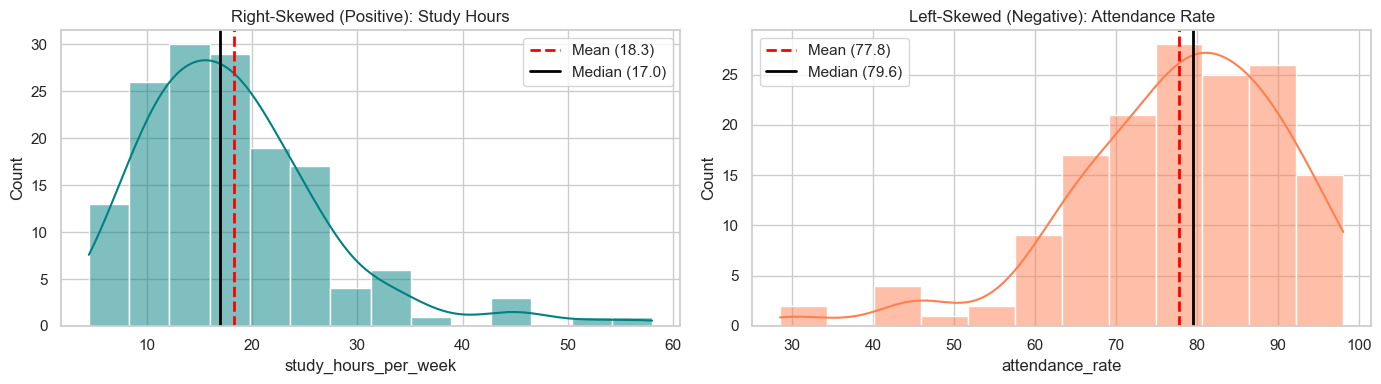

In [1]:
# Print skewness of all numerical columns
print("--- SKEWNESS VALUES ---")
print(df.select_dtypes(include=np.number).skew().round(2))

# Plot the two contrasting distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Right Skewed
sns.histplot(df['study_hours_per_week'], kde=True, ax=axes[0], color='teal')
axes[0].axvline(df['study_hours_per_week'].mean(), color='red', linestyle='--', linewidth=2, label='Mean (18.3)')
axes[0].axvline(df['study_hours_per_week'].median(), color='black', linestyle='-', linewidth=2, label='Median (17.0)')
axes[0].set_title("Right-Skewed (Positive): Study Hours")
axes[0].legend()

# 2. Left Skewed
sns.histplot(df['attendance_rate'], kde=True, ax=axes[1], color='coral')
axes[1].axvline(df['attendance_rate'].mean(), color='red', linestyle='--', linewidth=2, label='Mean (77.8)')
axes[1].axvline(df['attendance_rate'].median(), color='black', linestyle='-', linewidth=2, label='Median (79.6)')
axes[1].set_title("Left-Skewed (Negative): Attendance Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

**👀 What to point at on screen:**
- Show the red dashed line (mean) vs black solid line (median).
- Explain: *"The mean is always pulled toward the tail! That's why the mean is called an 'outlier magnet'."*

---
## Part 4: Percentiles, Quartiles & Outlier Detection (Tukey's 1.5 $\times$ IQR Rule)

**🗣️ What to say:**  
- $Q_1$ = 25th percentile (25% of students scored below this).
- $Q_3$ = 75th percentile (75% of students scored below this).
- **IQR (Interquartile Range)** = $Q_3 - Q_1$ (The spread of the middle 50%).
- **Tukey's Rule**: Anything beyond $1.5 \times \text{IQR}$ outside the box is statistically an outlier!

In [1]:
# Example: Outliers in study_hours_per_week
q1_study = df['study_hours_per_week'].quantile(0.25)
q3_study = df['study_hours_per_week'].quantile(0.75)
iqr_study = q3_study - q1_study

lower_study = q1_study - 1.5 * iqr_study
upper_study = q3_study + 1.5 * iqr_study

print(f"Q1: {q1_study:.2f} hrs | Q3: {q3_study:.2f} hrs | IQR: {iqr_study:.2f} hrs")
print(f"Lower Fence: {lower_study:.2f} hrs (any student below this is low outlier)")
print(f"Upper Fence: {upper_study:.2f} hrs (any student above this is high outlier)")

# Filter outlier students
study_outliers = df[(df['study_hours_per_week'] < lower_study) | (df['study_hours_per_week'] > upper_study)]
print(f"\nNumber of study hour outliers: {len(study_outliers)}")
study_outliers[['student_id', 'study_hours_per_week', 'final_exam_score']]

Q1: 11.88 hrs | Q3: 22.20 hrs | IQR: 10.32 hrs
Lower Fence: -3.61 hrs (any student below this is low outlier)
Upper Fence: 37.69 hrs (any student above this is high outlier)

Number of study hour outliers: 6


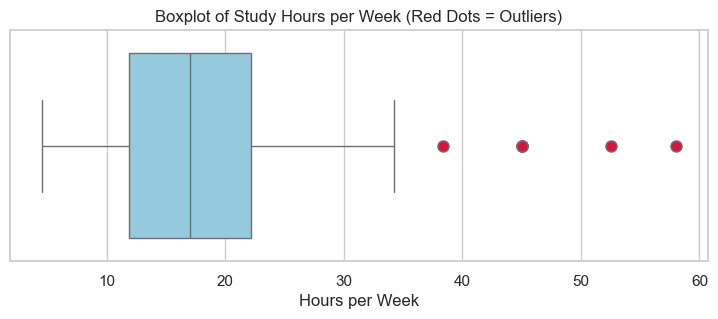

In [1]:
# Visualizing with a Boxplot
plt.figure(figsize=(9, 3))
sns.boxplot(x=df['study_hours_per_week'], color='skyblue', flierprops=dict(marker='o', markersize=8, markerfacecolor='crimson'))
plt.title("Boxplot of Study Hours per Week (Red Dots = Outliers)")
plt.xlabel("Hours per Week")
plt.show()

### 🧪 In-Class Exercise 2 (Give students 7 minutes)
**Prompt for students:**
> *"Now find the outliers in `attendance_rate`. Compute Q1, Q3, IQR, and find any students below the lower bound. Who are these students?"*

In [1]:
# ✅ SOLUTION TO EXERCISE 2:
q1_att = df['attendance_rate'].quantile(0.25)
q3_att = df['attendance_rate'].quantile(0.75)
iqr_att = q3_att - q1_att

lower_att = q1_att - 1.5 * iqr_att
upper_att = q3_att + 1.5 * iqr_att

att_outliers = df[df['attendance_rate'] < lower_att]
print(f"Attendance Q1: {q1_att:.2f}%, Q3: {q3_att:.2f}%, IQR: {iqr_att:.2f}%")
print(f"Lower Bound cutoff: {lower_att:.2f}%")
print(f"Found {len(att_outliers)} attendance outliers:")
att_outliers[['student_id', 'attendance_rate', 'final_exam_score', 'study_hours_per_week']]

Attendance Q1: 71.20%, Q3: 86.95%, IQR: 15.75%
Lower Bound cutoff: 47.57%
Found 7 attendance outliers:


**🗣️ Question for the class:**  
*"Should we delete these 7 students from our dataset?"*  
**Answer:** *"No! These are real students who attended < 47% of classes. An academic advisor needs to identify them, not pretend they don't exist!"*

---
## Part 5: Comparative Statistics with `groupby()` + `agg()`

**🗣️ What to say:**  
*"Summary stats for the whole class are helpful, but what if we want to compare different groups? For instance: Do students who study in groups perform better than solo students? `groupby()` + `agg()` is the ultimate tool for this."*

In [1]:
# Compare final_exam_score between students in a study group vs not
group_comparison = df.groupby('study_group')['final_exam_score'].agg([
    'count',
    'mean',
    'median',
    'std'
]).round(2)

group_comparison

### 🧪 In-Class Exercise 3 (Give students 5 minutes)
**Prompt for students:**
> *"Group by `prep_course` (Completed vs None) and find the mean and median for BOTH `study_hours_per_week` and `final_exam_score`."*

In [1]:
# ✅ SOLUTION TO EXERCISE 3:
prep_comparison = df.groupby('prep_course').agg(
    count=('student_id', 'count'),
    mean_hours=('study_hours_per_week', 'mean'),
    median_hours=('study_hours_per_week', 'median'),
    mean_score=('final_exam_score', 'mean'),
    median_score=('final_exam_score', 'median')
).round(2)

prep_comparison

**🗣️ Discussion to highlight:**  
*"Notice: Students who completed the prep course have an average final score of ~78.7 vs ~73.4 for those who did not, even though both groups studied about the same number of hours (~18 hrs)! The prep course actually helped efficiency!"*

---
## Part 6: Relationships - Covariance & Correlation

**🗣️ What to say:**  
- **Covariance**: Measures if two variables increase together ($+$) or opposite ($-$). But its value is hard to interpret because it depends on the units ($hours \times points$).
- **Pearson Correlation ($r$)**: Standardized covariance! It always sits strictly between $-1.0$ and $+1.0$.
  - $+1.0$: Perfect positive line
  - $0.0$: No linear relationship
  - $-1.0$: Perfect negative line

In [1]:
# Covariance vs Correlation between study hours and final score
cov_val = df['study_hours_per_week'].cov(df['final_exam_score'])
corr_val = df['study_hours_per_week'].corr(df['final_exam_score'])

print(f"Covariance:  {cov_val:.2f}  (Units: hours * points - hard to interpret)")
print(f"Correlation: {corr_val:.2f}  (Scale-independent between -1 and +1 - easy to interpret!)")

Covariance:  40.43  (Units: hours * points - hard to interpret)
Correlation: 0.48  (Scale-independent between -1 and +1 - easy to interpret!)


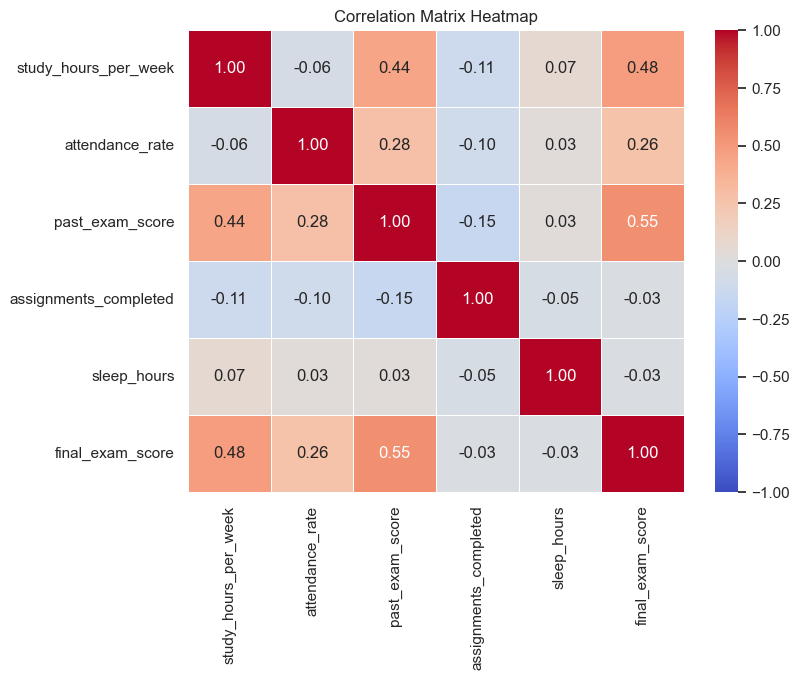

In [1]:
# Correlation Heatmap across all numerical features
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

### 🧪 Final In-Class Challenge (7 minutes)
**Prompt for students:**
> *"Look at the correlation heatmap:
> 1. Which variable has the strongest correlation with final exam score?
> 2. What is the correlation between `sleep_hours` and `final_exam_score`?
> 3. Why does correlation NOT mean causation?"*

In [1]:
# ✅ SOLUTION TO FINAL CHALLENGE:
print("Correlations with final_exam_score (highest to lowest):")
print(corr_matrix['final_exam_score'].sort_values(ascending=False))

# 🗣️ What to conclude the class with:
# 1. Past exam score (0.55) and study hours (0.48) are the biggest drivers.
# 2. Sleep hours has correlation near 0 (-0.03). Sleeping 10 hours won't magically pass the exam!
# 3. Correlation != Causation: Just because study hours correlates with score doesn't mean 
#    staring at a book for 50 hours guarantees an A. Quality of study and prior knowledge matter!

Correlations with final_exam_score (highest to lowest):
final_exam_score         1.00
past_exam_score          0.55
study_hours_per_week     0.48
attendance_rate          0.26
assignments_completed   -0.03
sleep_hours             -0.03
Name: final_exam_score, dtype: float64


---
## 🎓 Class Summary (Last 5 minutes on the whiteboard)
1. **`describe()`**: Your first snapshot of any new dataset.
2. **Mean vs Median**: Mean follows the tail; Median represents the middle.
3. **IQR**: Robust measure of spread; foundation for Tukey's outlier detection.
4. **`groupby().agg()`**: The tool for comparing subgroups.
5. **Correlation**: Tells you how strongly two features move together, but beware of causation assumptions!